# Baseline Model – TF-IDF + Logistic Regression

In this notebook we build a simple baseline model for hallucination detection
using classical NLP features.

## Goal
Given a prompt–response pair, predict the probability that the response
contains a hallucination.

## Why this baseline?
- Simple and interpretable
- Serves as a lower bound for performance
- Helps justify more advanced models later (embeddings, transformers)

## Dataset
- Source: HaluEval
- Label: 1 = hallucination, 0 = non-hallucination
- Input text: concatenation of prompt and response


In [40]:
# Core
import sys
from pathlib import Path
import pandas as pd
import numpy as np

# ML / NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import confusion_matrix, roc_auc_score
from src.utils import evaluate_split

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 200)

# Ensure repo root is in PYTHONPATH
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Use explicit import to avoid module/function confusion
from src.data.load_splits import load_splits

train_df, val_df, test_df = load_splits(root=ROOT)
print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)


Train: (51605, 6)
Val:   (6451, 6)
Test:  (6451, 6)


יצירת שדה טקסט מאוחד (Prompt + Response)

בשלב זה אנו יוצרים שדה טקסט מאוחד המשלב את ה־prompt (קלט המשתמש) ואת ה־response (פלט המודל).

למה זה חשוב?

מטרת המחקר היא לזהות הזיות בפלט של מודלים שפתיים, אך הזיה אינה תלויה רק בפלט עצמו, אלא גם ב־הקשר שבו הוא נוצר.

לדוגמה:

תשובה עשויה להיות נכונה בהקשר אחד,

אך להיחשב להזיה כאשר היא ניתנת לפרומפט אחר.

שיקולים מתודולוגיים:

מודלים מבוססי Bag-of-Words ו־TF-IDF אינם תומכים באופן טבעי בייצוג זוגות (prompt, response).

שילוב הטקסטים לשדה אחד מאפשר למודל:

“לראות” את ההקשר,

ללמוד דפוסים לשוניים המעידים על חוסר עקביות בין שאלה לתשובה.

In [41]:
def build_text(df: pd.DataFrame) -> pd.Series:
    """Combine prompt and response into a single text field."""
    return df["prompt"].fillna("").astype(str) + "\n\n" + df["response"].fillna("").astype(str)

X_train_text = build_text(train_df)
X_val_text   = build_text(val_df)
X_test_text  = build_text(test_df)

y_train = train_df["label"].astype(int)
y_val   = val_df["label"].astype(int)
y_test  = test_df["label"].astype(int)

print("Text ready:", X_train_text.shape, X_val_text.shape, X_test_text.shape)


Text ready: (51605,) (6451,) (6451,)


In [42]:
# Quick sanity check: show before/after for 2 rows
tmp = train_df.sample(2, random_state=42)[["task","label","prompt","response"]].copy()
tmp["combined_text"] = build_text(tmp)
tmp[["task","label","combined_text"]]


,task,label,combined_text
672,qa,0,What is the nickname of the leader of Christy Kinahan's rival gang?\n\nThe Monk
5428,qa,0,"What date was the screenwrither of the film directed by Garry Marshall born on?\n\nJuly 1, 1971"


Vectorize

In [43]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=100_000,
    ngram_range=(1, 2),
    min_df=2
)

X_train = vectorizer.fit_transform(X_train_text)
X_val   = vectorizer.transform(X_val_text)
X_test  = vectorizer.transform(X_test_text)

print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)


X_train: (51605, 100000) | X_val: (6451, 100000) | X_test: (6451, 100000)


Train model

In [44]:
clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

clf.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

Evaluate (VAL + TEST)

In [45]:
val_metrics  = evaluate_split("val", clf, X_val, y_val)
test_metrics = evaluate_split("test", clf, X_test, y_test)



val metrics:
  accuracy = 0.4964
  f1       = 0.4842
  precision= 0.4623
  recall   = 0.5083
  confusion matrix:
[[1677 1774]
 [1475 1525]]

test metrics:
  accuracy = 0.4950
  f1       = 0.4810
  precision= 0.4606
  recall   = 0.5033
  confusion matrix:
[[1683 1768]
 [1490 1510]]


ROC-AUC

In [46]:
y_val_prob = clf.predict_proba(X_val)[:, 1]
print("VAL roc_auc:", roc_auc_score(y_val, y_val_prob))


VAL roc_auc: 0.5361415531729934


Confusion matrix

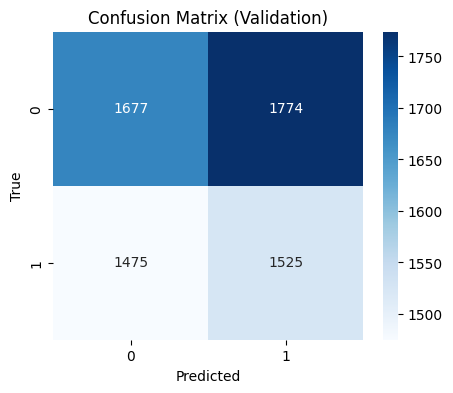

In [47]:
y_val_pred = clf.predict(X_val)
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Validation)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
